State   Formula                     Counts (1024 shots)
Phi+    (|00>+|11>)/sqrt2           {'00': 507, '11': 517}
Phi-    (|00>-|11>)/sqrt2           {'11': 525, '00': 499}
Psi+    (|01>+|10>)/sqrt2           {'01': 492, '10': 532}
Psi-    (|01>-|10>)/sqrt2           {'10': 533, '01': 491}


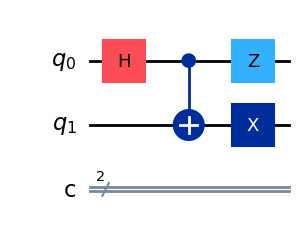

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, concurrence, purity
from qiskit_aer import AerSimulator
# All four Bell states, built from Phi+ by local Pauli corrections on qubit 0/1
def bell_state(kind):
    qc = QuantumCircuit(2, 2)
    qc.h(0); qc.cx(0, 1)  # Phi+
    if kind == "Phi-":
        qc.z(0)  # relative phase flip
    elif kind == "Psi+":
        qc.x(1)  # bit flip on qubit 1
    elif kind == "Psi-":
        qc.x(1); qc.z(0)  # both
    return qc

print(f"{'State':<8}{'Formula':<28}{'Counts (1024 shots)'}")
for kind, formula in [("Phi+", "(|00>+|11>)/sqrt2"), ("Phi-", "(|00>-|11>)/sqrt2"),
                       ("Psi+", "(|01>+|10>)/sqrt2"), ("Psi-", "(|01>-|10>)/sqrt2")]:
    qc = bell_state(kind)
    qc.measure([0, 1], [0, 1])
    counts = AerSimulator().run(qc, shots=1024).result().get_counts()
    print(f"{kind:<8}{formula:<28}{counts}")

display(bell_state("Psi-").draw(output='mpl', style='iqp'))
